In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

# Load processed data
df = pd.read_csv('../data/train_processed.csv', parse_dates=['date'])

print(f"Shape: {df.shape}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"\nReady for modeling.")

Shape: (2950992, 33)
Date range: 2013-01-29 00:00:00 to 2017-08-15 00:00:00

Ready for modeling.


Now lets do train test slit.
Everything before 30 days of data is tran data 


In [3]:
split_date = '2017-07-16'

train_data = df[df['date'] < split_date]
test_data = df[df['date'] >= split_date]

# Define features and target
feature_columns = [
    'day_of_week', 'day_of_month', 'month', 'year', 'week_of_year',
    'is_weekend', 'is_payday', 'is_month_start',
    'store_nbr', 'cluster', 'type_encoded', 'city_encoded', 'state_encoded',
    'family_encoded', 'onpromotion', 'dcoilwtico',
    'is_national_holiday', 'is_regional_holiday', 'is_transferred_holiday', 'is_holiday',
    'lag_7', 'lag_14', 'lag_28',
    'rolling_7_mean', 'rolling_14_mean', 'rolling_28_mean'
]

X_train = train_data[feature_columns]
y_train = train_data['sales']
X_test = test_data[feature_columns]
y_test = test_data['sales']

print(f"Training set: {X_train.shape[0]:,} rows  ({train_data['date'].min().date()} to {train_data['date'].max().date()})")
print(f"Test set:     {X_test.shape[0]:,} rows  ({test_data['date'].min().date()} to {test_data['date'].max().date()})")
print(f"\nFeatures: {X_train.shape[1]}")
print(f"\nWhy time-based split matters:")
print(f"  - Random split would let the model 'peek' at future data")
print(f"  - Time split simulates real forecasting: train on past, predict future")

Training set: 2,895,750 rows  (2013-01-29 to 2017-07-15)
Test set:     55,242 rows  (2017-07-16 to 2017-08-15)

Features: 26

Why time-based split matters:
  - Random split would let the model 'peek' at future data
  - Time split simulates real forecasting: train on past, predict future


Training set: 2,895,750 rows  (2013-01-29 to 2017-07-15)
Test set:     55,242 rows  (2017-07-16 to 2017-08-15)

Features: 26

Why time-based split matters:
  - Random split would let the model 'peek' at future data
  - Time split simulates real forecasting: train on past, predict future

In [4]:
# Predict sales = whatever it was 7 days ago
baseline_predictions = test_data['lag_7'].values
actual = y_test.values

# Evaluation metrics
def evaluate_model(name, actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    
    # Mean Absolute Percentage Error (avoid division by zero)
    mask = actual > 0
    mape = np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100
    
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  MAE:  {mae:,.2f}")
    print(f"  RMSE: {rmse:,.2f}")
    print(f"  MAPE: {mape:.2f}%")
    
    return {'name': name, 'mae': mae, 'rmse': rmse, 'mape': mape}

# Store results for comparison later
results = []
results.append(evaluate_model("Naive Baseline (lag_7)", actual, baseline_predictions))


  Naive Baseline (lag_7)
  MAE:  84.63
  RMSE: 310.16
  MAPE: 47.08%


Model 2: XGBoost. This is where our 26 engineered features earn their keep

In [6]:
import sys
!{sys.executable} -m pip install xgboost

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    random_state=42,
    n_jobs=-1,
    verbosity=1
)

print("Training XGBoost... (this may take a few minutes)")
xgb_model.fit(X_train, y_train)

# Predict
xgb_predictions = xgb_model.predict(X_test)

# XGBoost can predict negative values, but sales can't be negative
xgb_predictions = np.clip(xgb_predictions, 0, None)

results.append(evaluate_model("XGBoost", actual, xgb_predictions))

# Improvement over baseline
baseline_mae = results[0]['mae']
xgb_mae = results[1]['mae']
improvement = ((baseline_mae - xgb_mae) / baseline_mae) * 100
print(f"\nImprovement over baseline: {improvement:.1f}%")

Training XGBoost... (this may take a few minutes)

  XGBoost
  MAE:  57.79
  RMSE: 200.73
  MAPE: 38.25%

Improvement over baseline: 31.7%


What features did the xgboost learned lets see:

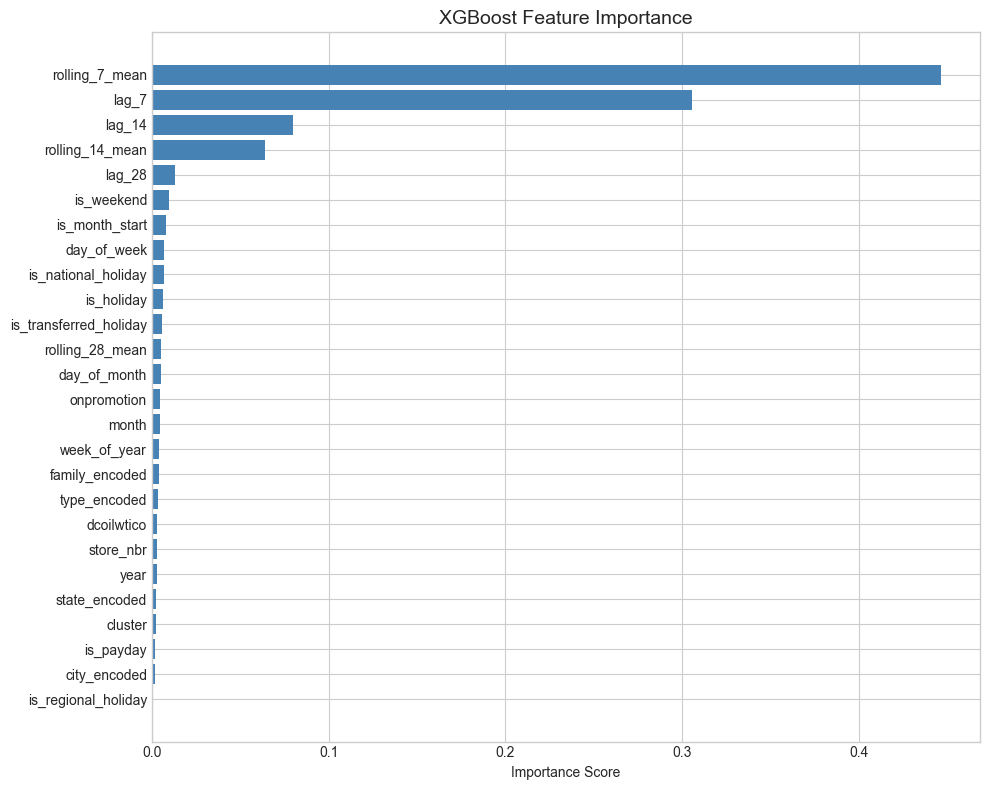


Top 5 features:
  rolling_7_mean             0.4463
  lag_7                      0.3058
  lag_14                     0.0795
  rolling_14_mean            0.0640
  lag_28                     0.0131


In [10]:
#Feature importance
importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(importance['feature'], importance['importance'], color='steelblue')
ax.set_title('XGBoost Feature Importance', fontsize=14)
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 5 features:")
for _, row in importance.tail(5).iloc[::-1].iterrows():
    print(f"  {row['feature']:25s}  {row['importance']:.4f}")

let's visualize how well our predictions actually match reality

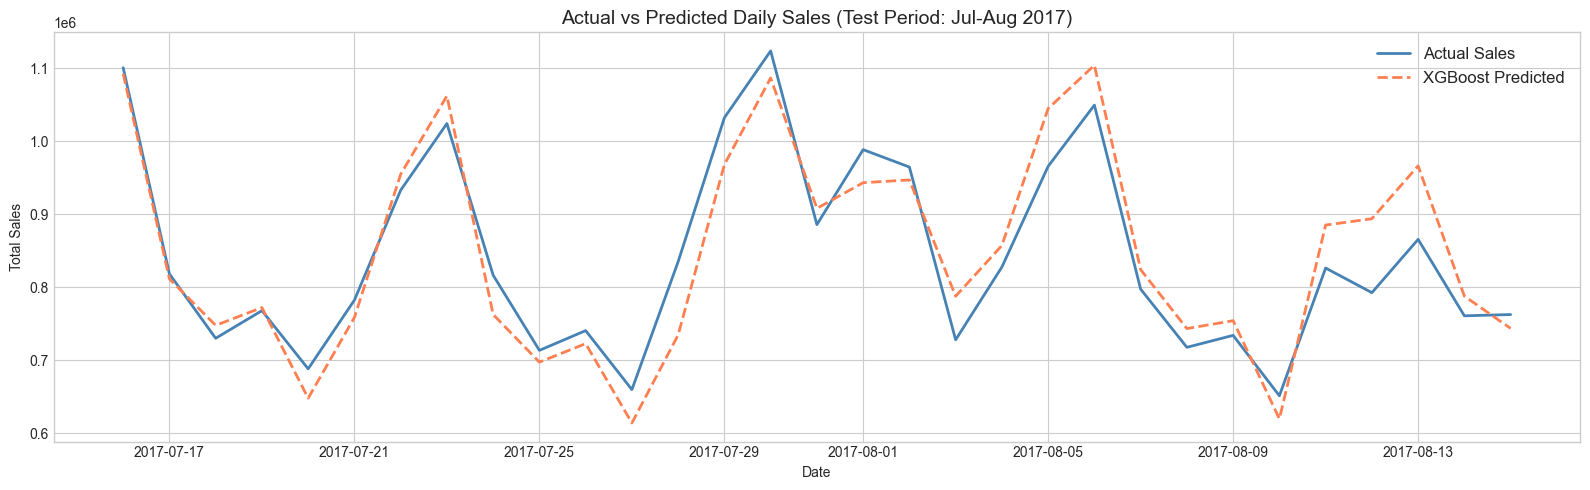

In [11]:
# Aggregate predictions and actual by date
test_comparison = test_data[['date']].copy()
test_comparison['actual'] = actual
test_comparison['predicted'] = xgb_predictions

daily_comparison = test_comparison.groupby('date').agg(
    actual=('actual', 'sum'),
    predicted=('predicted', 'sum')
).reset_index()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(daily_comparison['date'], daily_comparison['actual'], 
        label='Actual Sales', linewidth=2, color='steelblue')
ax.plot(daily_comparison['date'], daily_comparison['predicted'], 
        label='XGBoost Predicted', linewidth=2, color='coral', linestyle='--')
ax.set_title('Actual vs Predicted Daily Sales (Test Period: Jul-Aug 2017)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Total Sales')
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

Model 3: LightGBM. This is XGBoost's faster cousin, often performs equally well or better.

In [12]:
import lightgbm as lgb

lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

print("Training LightGBM...")
lgb_model.fit(X_train, y_train)

lgb_predictions = lgb_model.predict(X_test)
lgb_predictions = np.clip(lgb_predictions, 0, None)

results.append(evaluate_model("LightGBM", actual, lgb_predictions))

# Compare all models
print(f"\n{'='*50}")
print(f"  MODEL COMPARISON")
print(f"{'='*50}")
print(f"  {'Model':<30} {'MAE':>8} {'RMSE':>10} {'MAPE':>8}")
print(f"  {'-'*56}")
for r in results:
    print(f"  {r['name']:<30} {r['mae']:>8.2f} {r['rmse']:>10.2f} {r['mape']:>7.2f}%")

Training LightGBM...

  LightGBM
  MAE:  61.57
  RMSE: 206.86
  MAPE: 44.26%

  MODEL COMPARISON
  Model                               MAE       RMSE     MAPE
  --------------------------------------------------------
  Naive Baseline (lag_7)            84.63     310.16   47.08%
  XGBoost                           57.79     200.73   38.25%
  LightGBM                          61.57     206.86   44.26%


We find that  cgboost performed well overall

In [14]:
import pickle
from sklearn.preprocessing import LabelEncoder

# Recreate label encoders from the data
cat_columns = ['family', 'city', 'state', 'type']
label_encoders = {}
for col in cat_columns:
    le = LabelEncoder()
    le.fit(df[col])
    label_encoders[col] = le

# Save the XGBoost model
with open('../models/xgb_demand_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

# Save the label encoders
with open('../models/label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)

# Save feature column list
with open('../models/feature_columns.pkl', 'wb') as f:
    pickle.dump(feature_columns, f)

print("Models and encoders saved to /models directory")
print(f"\nFiles saved:")
print(f"  - xgb_demand_model.pkl")
print(f"  - label_encoders.pkl") 
print(f"  - feature_columns.pkl")

Models and encoders saved to /models directory

Files saved:
  - xgb_demand_model.pkl
  - label_encoders.pkl
  - feature_columns.pkl


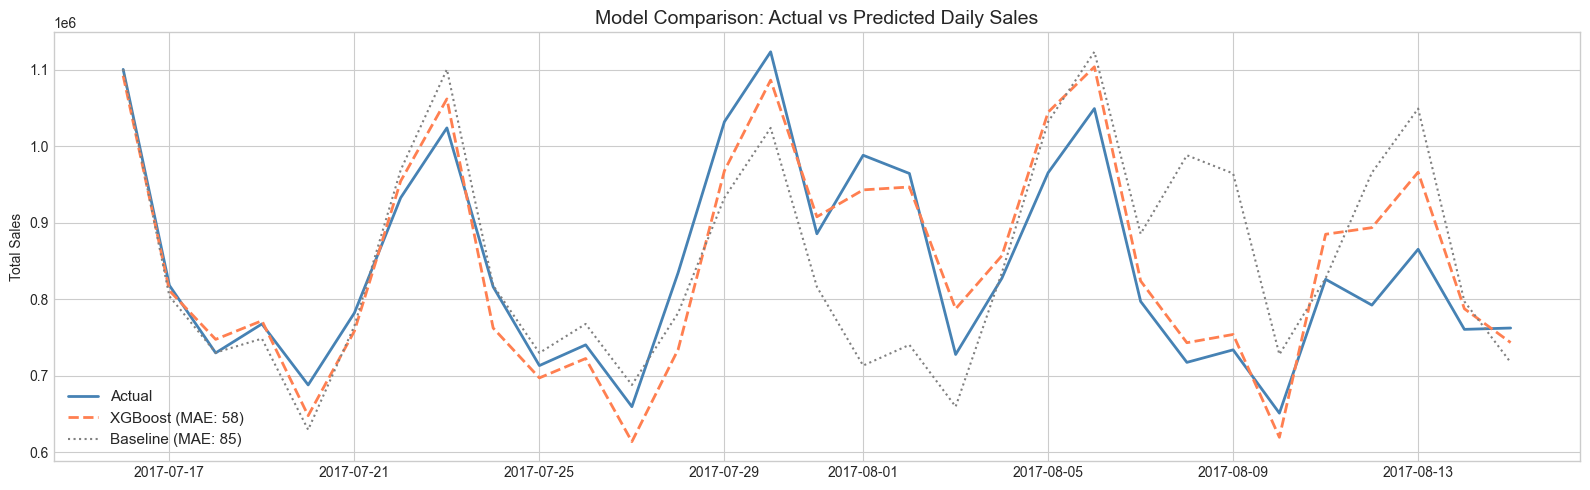

In [15]:
# Final visualization: all models compared
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(daily_comparison['date'], daily_comparison['actual'], 
        label='Actual', linewidth=2, color='steelblue')
ax.plot(daily_comparison['date'], daily_comparison['predicted'], 
        label=f'XGBoost (MAE: {results[1]["mae"]:.0f})', linewidth=2, color='coral', linestyle='--')

baseline_comp = test_data[['date']].copy()
baseline_comp['predicted'] = baseline_predictions
baseline_daily = baseline_comp.groupby('date')['predicted'].sum().reset_index()
ax.plot(baseline_daily['date'], baseline_daily['predicted'], 
        label=f'Baseline (MAE: {results[0]["mae"]:.0f})', linewidth=1.5, color='gray', linestyle=':')

ax.set_title('Model Comparison: Actual vs Predicted Daily Sales', fontsize=14)
ax.set_ylabel('Total Sales')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()